#**Project 1**

Iris Wu

Data 201





##**Introduction**

For this project, I used a dataset containing contemporary artworks that were auctioned between 1960 and 2015. This dataset provides insights on top-selling contemporary artists and auction houses, trends in the art market, and how artworks are valued.

Dataset Citation: Kyung-Ah Lee, Jaeseok Park, Selin Goree, et al. 2024. Social signals predict contemporary art prices better than visual features, particularly in emerging markets. Scientific Reports 14, (2024), 11615. https://doi.org/10.1038/s41598-024-60957-z

##**Dataset Structure**

In [1]:
#load the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

In [2]:
#load the datasets
from google.colab import drive
drive.mount('/content/drive')


df_art = pd.read_csv("/content/drive/MyDrive/transactions.csv", encoding= "latin1")
df_art.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_10392/1809045954.py:6: DtypeWarning: Columns (8,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df_art = pd.read_csv("/content/drive/MyDrive/transactions.csv", encoding= "latin1")


,case_id,artfacts_id,alive_id,sales_id,lot_num,artist_name,lot_title,nationality,Year of Birth,year_of_artwork,...,est_currency,materials,height,width,depth,provenance,img_link,biography,size (inch by inch),price per inch
0,1,NaN,NaN,1380,464910,Ai Weiwei,Map of China,Chinese,1957,2004.0,...,0,1,20,79,63,NaN,"<div class=""image""><a href=""/asi/lots/464910"">...",Y,1580,102.717088607595
1,2,NaN,NaN,1380,493949,Ai Weiwei,Tianammen fuck off,Chinese,1957,NaN,...,1,2,16,23,0,NaN,"<div class=""image""><a href=""/asi/lots/493949"">...",Y,368,26.1776358695652
2,3,NaN,NaN,1380,510067,Ai Weiwei,Coloured pots,Chinese,1957,2006.0,...,0,1,13,9,59,NaN,"<div class=""image""><a href=""/asi/lots/510067"">...",Y,117,912.578632478633
3,4,NaN,NaN,1380,510068,Ai Weiwei,Untitled,Chinese,1957,1997.0,...,0,1,25,25,16,NaN,"<div class=""image""><a href=""/asi/lots/510068"">...",Y,625,82.000672
4,5,NaN,NaN,1380,3295772,Ai Weiwei,Gift from Beijing,Chinese,1957,2002.0,...,0,1,3,15,10,Provenance available in the auction catalogue.,"<div class=""image""><a href=""/asi/lots/3295772""...",Y,45,180.325555555556


In [3]:
#size of dataset
rows, columns = df_art.shape
print(f"The dataset has {rows} rows and {columns} columns")


The dataset has 114283 rows and 38 columns


###**Relevant Variables**

The following variables are used in this project:

|  **Name** | **Definition**  |  **Type** |
|---|---|---|
| artist_name  | Name of artist  | Categorical  |
|  lot_title |  Name of artwork sold |  Categorical |
|  nationality |  Nationality of artist |  Categorical |
|price_usd   | Nominal auction price in USD of an artwork  | Quantitative  |                                               
|  event_year | Year auction was held  |  Discrete |
|  estimate_min | Minimum estimate of an artwork's nominal auction price in USD   |  Quantitative |
|estimate_max   |   Maximum estimate of an artwork's nominal auction price in USD | Quantitative  |
|  size (inch by inch) |  Size in inches of an artwork | Quantitative  |


##**Data Analyses**

###**Data Cleaning**

In [4]:
#delete columns that will not be used in this project
df_art1 = df_art.drop(["case_id",
             "artfacts_id",
             "alive_id",
             "sales_id",
             "lot_num",
             "Year of Birth",
             "year_of_artwork",
             "country",
             "lot",
             "cpi",
             "genre",
             "real_price_usd",
             "ln_real_price",
             "price_eur",
             "price_gbp",
             "event name",
             "auction_house",
             "event date",
             "bidding_currency",
             "currency",
             "Ham_Prem",
             "est_currency",
             "materials",
             "height",
             "width",
             "depth",
             "provenance",
             "img_link",
             "biography",
             "price per inch"], axis = 1)
df_art1.head()

,artist_name,lot_title,nationality,price_usd,event_year,estimate_min,estimate_max,size (inch by inch)
0,Ai Weiwei,Map of China,Chinese,190000,2006,"120,000","150,000",1580
1,Ai Weiwei,Tianammen fuck off,Chinese,11278,2006,"3,500","5,000",368
2,Ai Weiwei,Coloured pots,Chinese,125000,2006,"80,000","120,000",117
3,Ai Weiwei,Untitled,Chinese,60000,2006,"60,000","90,000",625
4,Ai Weiwei,Gift from Beijing,Chinese,9500,2006,"8,000","12,000",45


In [5]:
#remove NAs
df_art1 = df_art1.replace("", np.nan)
df_art2 = df_art1.dropna(subset = ["price_usd", "estimate_min", "estimate_max", "size (inch by inch)"])
df_art2.tail()

,artist_name,lot_title,nationality,price_usd,event_year,estimate_min,estimate_max,size (inch by inch)
114278,Zwelethu Mthethwa,Dogged Angels I,South African,4219,2014,"40,000","60,000",535.4904
114279,Zwelethu Mthethwa,Boy in bath,South African,3549,2014,"40,000","70,000",513.513
114280,Zwelethu Mthethwa,Man with woman holding a bird,South African,.,2014,"60,000","100,000",1059.0866
114281,Zwelethu Mthethwa,Good times,South African,12113,2014,"80,000","120,000",3318.7869
114282,Zwelethu Mthethwa,Lovers II,South African,.,2014,"3,000","5,000",436.464


###**Quantitative Variable**

**Research Question:** Between 1995 and 2015, how do estimated minimum and maximum auction prices of an artwork compare to its actual auction price? Do the estimated prices tend to over or underestimate the actual price?

Since most auctions held before 1995 did not have estimated price data, I focused on the time range from 1995 to 2015. For this question, I examined three quantitative variables: price_usd (the auction price of the artwork), estimate_min (the estimated minimum auction price of the artwork), and estimate_max (the estimated maximum auction price). All three variables are nominal prices  (i.e., not adjusted for inflation). To reduce the skew of the distributions, I applied log transformations to each variable.

In [6]:
#filter data to auctions between 1995 and 2015
df_art2.query("event_year >= 1995 and event_year <= 2015")
df_art2.head()

,artist_name,lot_title,nationality,price_usd,event_year,estimate_min,estimate_max,size (inch by inch)
0,Ai Weiwei,Map of China,Chinese,190000,2006,"120,000","150,000",1580
1,Ai Weiwei,Tianammen fuck off,Chinese,11278,2006,"3,500","5,000",368
2,Ai Weiwei,Coloured pots,Chinese,125000,2006,"80,000","120,000",117
3,Ai Weiwei,Untitled,Chinese,60000,2006,"60,000","90,000",625
4,Ai Weiwei,Gift from Beijing,Chinese,9500,2006,"8,000","12,000",45


In [7]:
df_art2 = df_art2.copy()
#convert variables to numbers for log transformation
num_cols = ["price_usd", "estimate_min", "estimate_max"]
#remove commas from columns
df_art2.loc[:, num_cols] = df_art2[num_cols].apply(lambda x: x.str.replace(",", ""))

In [8]:
#convert to numeric
df_art2["price_usd"] = pd.to_numeric(df_art2["price_usd"], errors = "coerce")
print(df_art2["price_usd"].dtype)

float64


In [9]:
df_art2["estimate_min"] = pd.to_numeric(df_art2["estimate_min"], errors = "coerce")
print(df_art2["estimate_min"].dtype)

int64


In [10]:
df_art2["estimate_max"] = pd.to_numeric(df_art2["estimate_max"], errors = "coerce")
print(df_art2["estimate_max"].dtype)


int64


In [11]:
_#apply log transformation to each variable
df_art2.loc[:, "log_price_usd"] = np.log(df_art2["price_usd"])

df_art2.loc[:, "log_estimate_min"] = np.log(df_art2["estimate_min"])

df_art2.loc[:, "log_estimate_max"] = np.log(df_art2["estimate_max"])

df_art2.head()

,artist_name,lot_title,nationality,price_usd,event_year,estimate_min,estimate_max,size (inch by inch),log_price_usd,log_estimate_min,log_estimate_max
0,Ai Weiwei,Map of China,Chinese,190000.0,2006,120000,150000,1580,12.154779,11.695247,11.918391
1,Ai Weiwei,Tianammen fuck off,Chinese,11278.0,2006,3500,5000,368,9.330609,8.160518,8.517193
2,Ai Weiwei,Coloured pots,Chinese,125000.0,2006,80000,120000,117,11.736069,11.289782,11.695247
3,Ai Weiwei,Untitled,Chinese,60000.0,2006,60000,90000,625,11.002100,11.002100,11.407565
4,Ai Weiwei,Gift from Beijing,Chinese,9500.0,2006,8000,12000,45,9.159047,8.987197,9.392662


In [12]:
#convert dataframe from wide to long format so data is easier to plot
df_artlong = df_art2[["artist_name", "lot_title", "log_price_usd", "log_estimate_min", "log_estimate_max"]].melt(id_vars = ["artist_name", "lot_title"], var_name = "price_type", value_name = "log_value")
df_artlong.head()

,artist_name,lot_title,price_type,log_value
0,Ai Weiwei,Map of China,log_price_usd,12.154779
1,Ai Weiwei,Tianammen fuck off,log_price_usd,9.330609
2,Ai Weiwei,Coloured pots,log_price_usd,11.736069
3,Ai Weiwei,Untitled,log_price_usd,11.002100
4,Ai Weiwei,Gift from Beijing,log_price_usd,9.159047


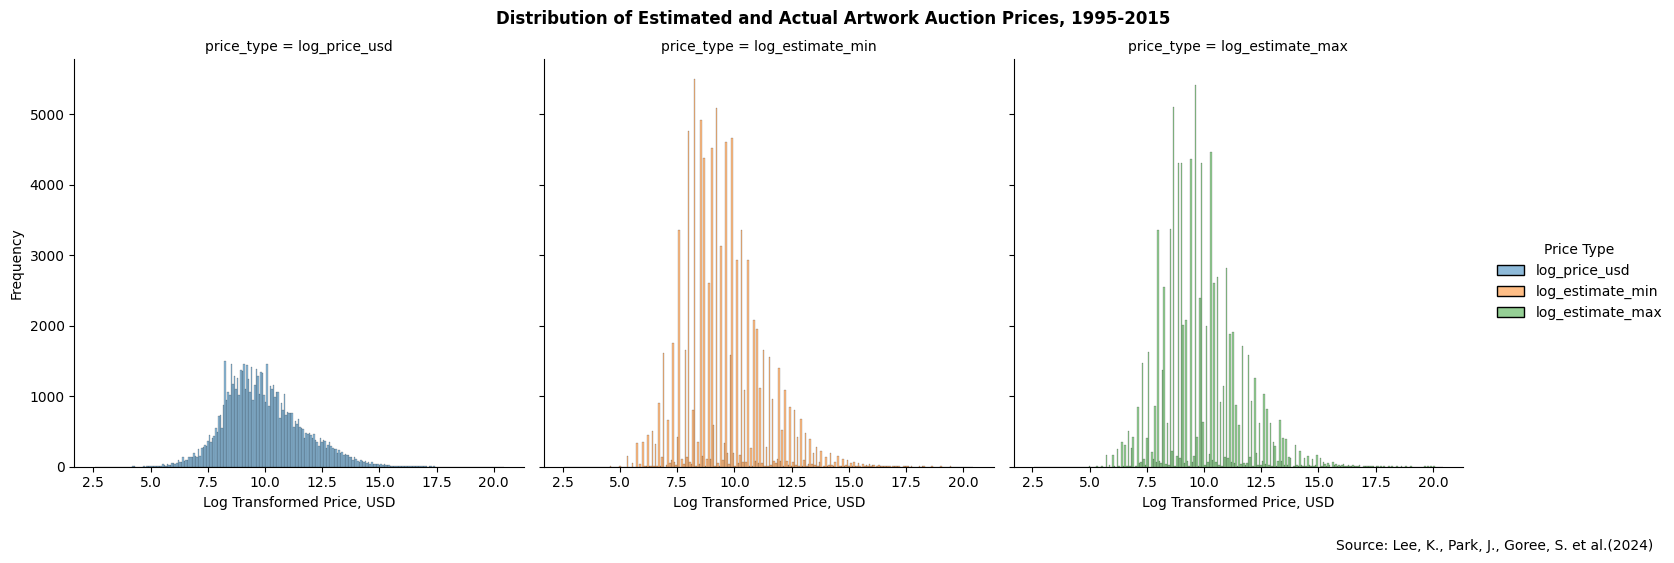

In [13]:
#plot the distrubutions
artdist = sns.displot(data = df_artlong, x = "log_value", col = "price_type", hue = "price_type", kind = "hist")
artdist.figure.suptitle("Distribution of Estimated and Actual Artwork Auction Prices, 1995-2015", fontweight = "bold", y = 1.03)
plt.figtext(0.8, -0.05, s = "Source: Lee, K., Park, J., Goree, S. et al.(2024)")
artdist.set_xlabels("Log Transformed Price, USD")
artdist.set_ylabels("Frequency")
artdist.legend.set_title("Price Type")
plt.show()

The distribution for each price type is relatively normal. This suggests that auction house estimates of artwork prices follow their actual prices. There is no systematic over and under-estimation of prices. Most artworks auctioned between 1995 and 2015 drew prices in a moderate range, with the median price around $20,000.

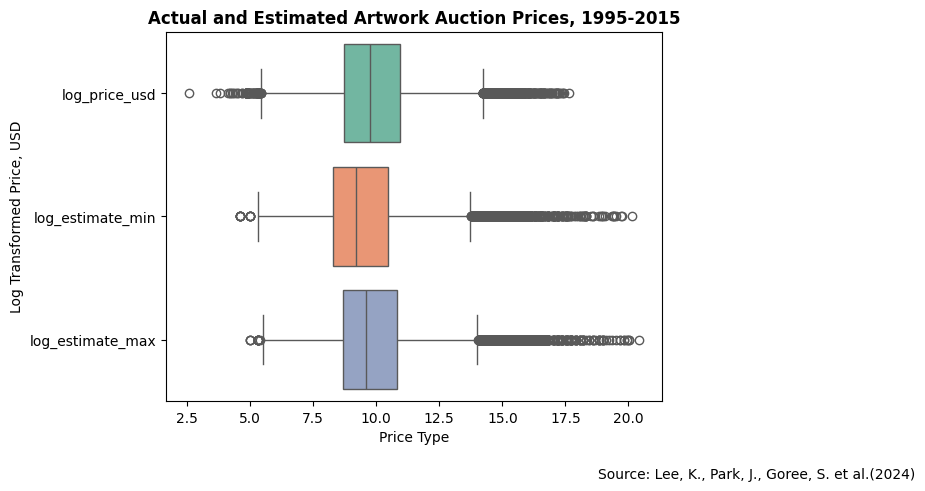

In [14]:
#plot as boxplots to see outliers
artbox = sns.boxplot(data = df_artlong, x = "log_value", y = "price_type", hue = "price_type", palette = "Set2")
plt.title ("Actual and Estimated Artwork Auction Prices, 1995-2015", fontweight = "bold")
plt.xlabel("Price Type")
plt.figtext(0.8, -0.05, s = "Source: Lee, K., Park, J., Goree, S. et al.(2024)")
plt.ylabel("Log Transformed Price, USD")
plt.show()

The boxplot confirms the results of the above histogram. Between 1995 and 2015, the median price for auctioned artworks was around $20,000. As expected, the estimated minimum median is slightly lower and the estimated maximum is slightly higher, but overall the estimated prices follow the actual price. Of note, the estimated prices have more outliers in the higher price range, which indicates that auction house estimates occasionally skew higher than actual prices.

###**Categorical Variable**

**Research Question:** Between 1995 and 2015, who were the top 10 highest-selling artists, in terms of price?


In [15]:
df_art3 = df_art2.groupby(["artist_name", "nationality"]).agg(total_sales = ("price_usd", "sum")).sort_values("total_sales", ascending = False).iloc[0:10, :]
df_art3.head()

,,total_sales
artist_name,nationality,
Gerhard Richter,German,1.390218e+09
Damien Hirst,British,5.357947e+08
Jeff Koons,American,3.905794e+08
Christopher Wool,American,2.862034e+08
Jasper Johns,American,2.580015e+08


In [16]:
#apply log transformation to total sales
df_art3.loc[:, "log_total_sales"] = np.log(df_art3["total_sales"])
df_art3.head()

,,total_sales,log_total_sales
artist_name,nationality,,
Gerhard Richter,German,1.390218e+09,21.052726
Damien Hirst,British,5.357947e+08,20.099262
Jeff Koons,American,3.905794e+08,19.783142
Christopher Wool,American,2.862034e+08,19.472213
Jasper Johns,American,2.580015e+08,19.368476


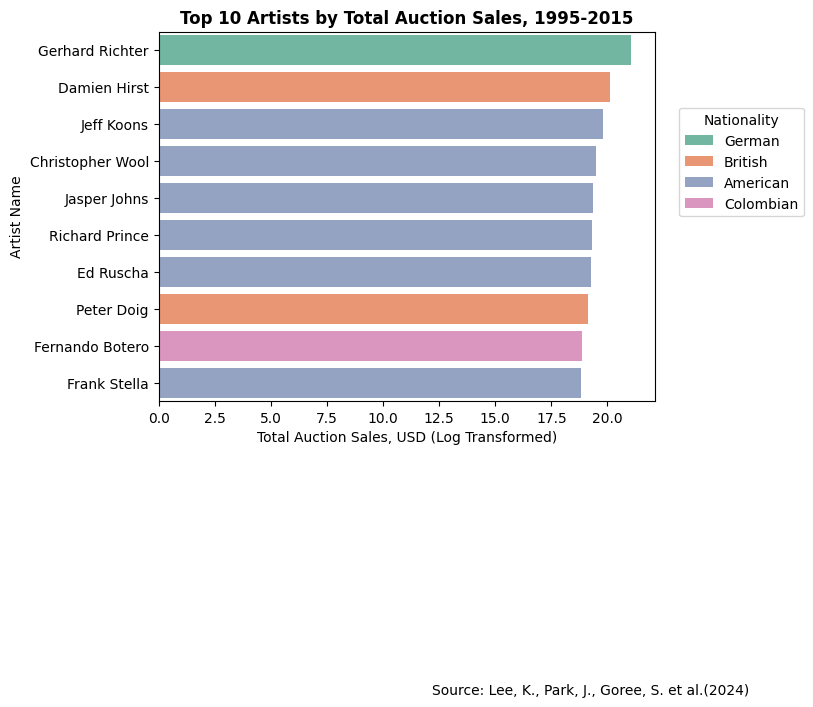

In [27]:
#plot the top 10 artists
sns.barplot(data = df_art3, x = "log_total_sales", y = "artist_name", hue = "nationality", palette = "Set2")
plt.title("Top 10 Artists by Total Auction Sales, 1995-2015", fontweight = "bold")
plt.xlabel("Total Auction Sales, USD (Log Transformed)")
plt.ylabel("Artist Name")
plt.figtext(0.8, -0.5, s = "Source: Lee, K., Park, J., Goree, S. et al.(2024)", ha = "center")
plt.legend(title = "Nationality", loc = (1.05, 0.5))
plt.show()


Among the top 10 highest-selling artists, six are American. Gerhard Richter is the only artist whoses total auction sales exceed one billion dollars, making him the number one selling artist at auctions between 1995 and 2015.

###**Relationship between Variables**

**Research Question:** Does the size of an artwork affect its auction price?

**Hypothesis:** The larger an artwork, the higher its auction price. Large artworks are made with more materials, require more effort and time, and cover more space (and therefore have more visual elements to draw the viewer's eye), which should increase their value.

In [18]:
#convert "size" column to numeric
df_art2["size (inch by inch)"] = pd.to_numeric(df_art2["size (inch by inch)"], errors = "coerce")
#remove zeros
df_art2 = df_art2[df_art2["size (inch by inch)"] > 0]

In [19]:
#apply log transformation to size
df_art2.loc[:, "log_size"] = np.log(df_art2["size (inch by inch)"])

Text(0.5, -0.02, 'Source: Lee, K., Park, J., Goree, S. et al.(2024)')

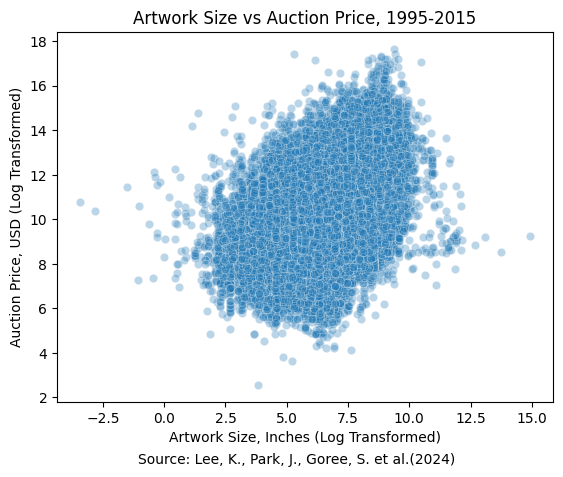

In [37]:
sns.scatterplot(data = df_art2, x = "log_size" , y = "log_price_usd", alpha = 0.3)
plt.title("Artwork Size vs Auction Price, 1995-2015")
plt.xlabel("Artwork Size, Inches (Log Transformed)")
plt.ylabel("Auction Price, USD (Log Transformed)")
plt.figtext(0.5, -0.02, "Source: Lee, K., Park, J., Goree, S. et al.(2024)", ha="center")


Surprisingly, there is no association between the size of an artwork and its auction price. Perhaps in the art world, size does not matter as much as the repuation of the artist who made the work. For example, a small Picasso painting would likely sell for higher than a large painting by a more contemporary artist.

###**Nonparametric Inference -- Median**

In [56]:
df_art4 = df_art2.query("event_year>=1960")

#extract 10% sample from the data
df_sample = df_art4.sample(frac = 0.1, random_state = 42)
df_clean = df_sample["log_price_usd"].dropna()
df_clean.shape


(7147,)

In [63]:
#bootstrap the medians
sample_n = 7147
sample = np.random.choice(df_clean, size = sample_n, replace = True)
n_bootstrap = 5000

bootstrap_medians = []
for b in range(n_bootstrap):
  bootstrap_medians.append(np.median(np.random.choice(sample, size = sample_n, replace = True)))

bootstrap_medians = np.array(bootstrap_medians)

#compute the 95% confidence interval
lower_bound = np.percentile(bootstrap_medians, 2.5)
upper_bound = np.percentile(bootstrap_medians, 97.5)
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

95% Confidence Intervals: [9.67, 9.77]


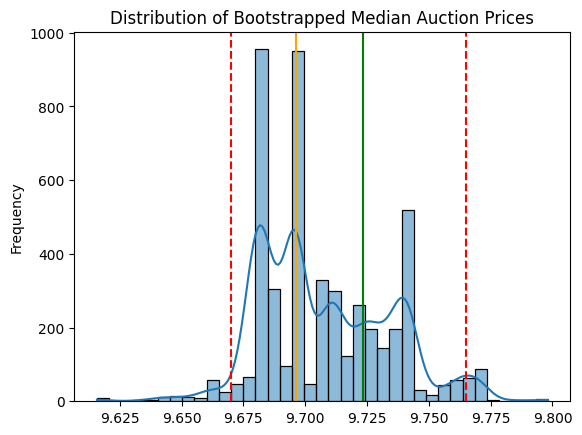

Bootstrapped Median: 9.7
Bootstrapped Std:0.0265
Sample Median: 9.72


In [65]:
sns.histplot(bootstrap_medians, kde = True, label = "Bootstrap")
plt.axvline(x = np.median(bootstrap_medians), linestyle = "-", color = "orange")
plt.axvline(x=lower_bound, ymin = 0, ymax = 1200, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin = 0, ymax = 1200, color='red', linestyle='--')
plt.axvline(x = np.median(df_clean), ymin = 0, ymax = 1200, color = "green")
plt.title("Distribution of Bootstrapped Median Auction Prices")
plt.ylabel("Frequency")
plt.show()

print(f"Bootstrapped Median: {np.median(bootstrap_medians):.3}")
print(f"Bootstrapped Std:{np.std(bootstrap_medians):.3}")
print(f"Sample Median: {np.median(df_clean):.3}")

Both the full sample median and bootstrapped median fall within the 95% confidence interval, with a minimal standard error of 0.0265. This indicates that the sample is representative of the data. The median price of artworks auctioned between 1960 and 2015 is around $16,700.

##**Conclusion & Recommendations**

There are several key takeaways:


1.   Estimated prices of auctioned artworks generally follow the actual prices. Auction houses' estimates are calibrated with the art market, although outliers toward the higher price range suggest that estimates may occasionally be skewed.
2.   A majority of the top-selling artists between 1995 and 2015 are American.
3. The median price of artwork auctioned between 1960 and 2015 is approximately $16,700. While artworks that sell for millions or billions of dollars make headlines, the median indicates that most artworks draw prices in a more moderate range.


In the future, I would like to examine the relationship between the age of an artist and their artwork sales. Do older artists' work sell for higher prices than younger ones, since they presumably have had more time to establish their reputation? Further, I examined the distribution of estimated prices and actual prices in this project, but more insights could be derived by testing how well estimated prices predict actual prices.
